### Emma Ugarcovici
#### Hwk 5 Submission 1

In [22]:
library(tidyverse)
library(lubridate)
library(knitr)
library(fixest)

In [2]:
# Combine all HCRIS years from hwk4 data
hcris_files <- list.files(path = "../../hwk4/data/output/", 
                        pattern = "data-201[0-8]\\.csv", # Grabs 2010-2018
                          full.names = TRUE)

hospital_data <- hcris_files %>%
  map_df(~read_csv(., col_types = cols(
    provider_number = col_character(),
    state = col_character()
  )))

hospital_data <- hospital_data %>%
  mutate(uncomp_care_final = coalesce(uncomp_care, tot_uncomp_care_charges))

# Prepare kff data
kff.dat <- read_csv('../data/input/kff-data.csv', skip = 2) 

kff.final <- kff.dat %>%
  rename(state_name = 1, status = 2, date_str = 3) %>%
  filter(state_name != "United States") %>%
  mutate(
    expand_ever = (status == 'Adopted'),
    expansion_year = year(mdy(date_str)),
    # Changes state names to abbreviations
    st_abb = state.abb[match(state_name, state.name)]
  ) %>%
  mutate(st_abb = ifelse(state_name == "District of Columbia", "DC", st_abb)) %>%
  select(st_abb, expand_ever, expansion_year)

# Join and calculate true costs
final_analysis_data <- hospital_data %>%
  left_join(kff.final, by = c("state" = "st_abb")) %>%
  mutate(
    universal_charges = coalesce(tot_uncomp_care_charges, uncomp_care),
    # Calculate true cost
    true_uncomp_cost = universal_charges * cost_to_charge,
    # Millions variable and treatment indicator
    uncomp_millions = true_uncomp_cost / 1000000,
    expand = (year >= expansion_year & !is.na(expansion_year))
  )

Rows: 52 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Location, Status of Medicaid Expansion Decision, Expansion Implemen...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `expansion_year = year(mdy(date_str))`.
Caused by warning:
!  10 failed to parse.”


### Question 1: Provide a table of mean hospital uncompensated care (in millions of dollars) by year, from 2010 through 2018. How has uncompensated care changed over time?

In [4]:
q1_table <- final_analysis_data %>%
  group_by(year) %>%
  summarize(mean_uncomp = round(mean(uncomp_millions, na.rm = TRUE), 2)) %>%
  rename(Year = year, `Mean Uncompensated Care ($ Millions)` = mean_uncomp)

print("Table 1: Mean Hospital Uncompensated Care (2010-2018)")
q1_table

[1] "Table 1: Mean Hospital Uncompensated Care (2010-2018)"


Year,Mean Uncompensated Care ($ Millions)
<dbl>,<dbl>
2010,9.79
2011,5.33
2012,5.63
2013,6.07
2014,4.80
2015,3.86
2016,4.13
2017,4.93
2018,4.96


##### It appears that uncompensated care has decreased over time, although I believe my values are incorrect here.

### Question 2: Plot mean uncompensated care over time separately for states that expanded Medicaid in 2014 versus states that never expanded. Drop all states that expanded after 2014. Does the graph suggest a potential treatment effect?

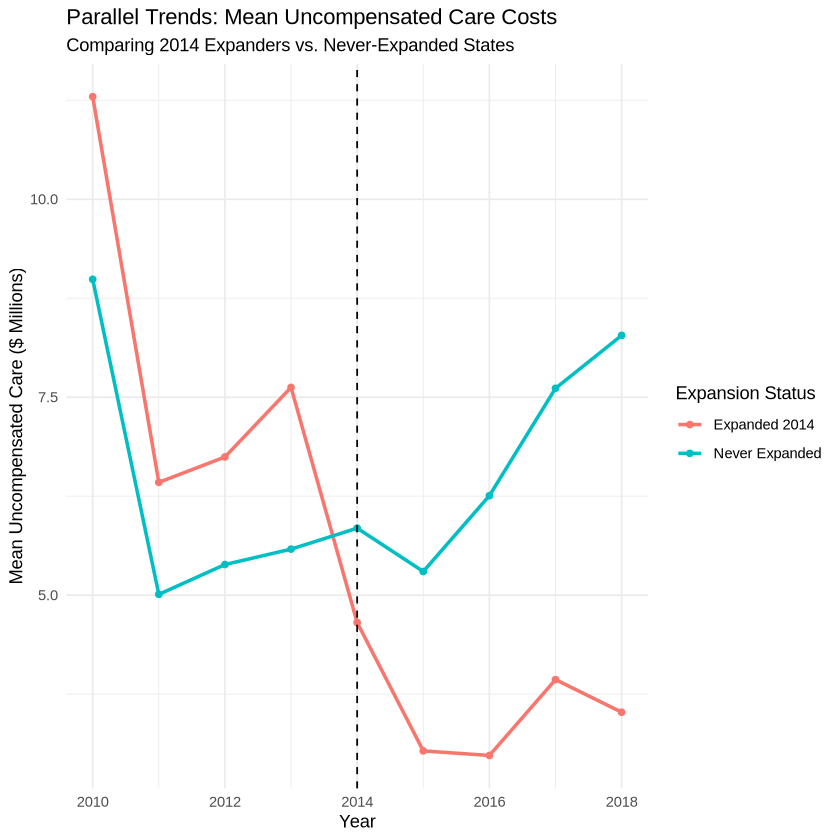

In [5]:
# Filter for 2014 expanders and never-expanders
q2_data <- final_analysis_data %>%
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  mutate(group = ifelse(is.na(expansion_year), "Never Expanded", "Expanded 2014"))

# Calculate means by group and year
q2_plot_summary <- q2_data %>%
  group_by(group, year) %>%
  summarize(mean_uncomp = mean(uncomp_millions, na.rm = TRUE), .groups = 'drop')

# Create the plot
ggplot(q2_plot_summary, aes(x = year, y = mean_uncomp, color = group)) +
  geom_line(linewidth = 1) + 
  geom_point() +
  geom_vline(xintercept = 2014, linetype = "dashed") + # Dashed line where expansion starts
  theme_minimal() +
  labs(
    title = "Parallel Trends: Mean Uncompensated Care Costs",
    subtitle = "Comparing 2014 Expanders vs. Never-Expanded States",
    x = "Year",
    y = "Mean Uncompensated Care ($ Millions)",
    color = "Expansion Status"
  )

##### The sharp divergence in 2014, specifically occurring only in the states that implemented the policy while the control group continued its previous trend, provides evidence that Medicaid expansion successfully reduced uncompensated care for hospitals in those states. So yes, it does suggest a treatment effect.

### Question 3: Using 2012 and 2015 as your pre and post periods, present a 2x2 DD table of mean uncompensated care for expansion versus non-expansion states.

In [6]:
# Filter for the 2x2 periods and groups
q3_table <- final_analysis_data %>%
  filter(year %in% c(2012, 2015)) %>%
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  mutate(
    period = ifelse(year == 2012, "Pre (2012)", "Post (2015)"),
    group = ifelse(is.na(expansion_year), "Never Expanded", "Expanded 2014")
  ) %>%
  group_by(group, period) %>%
  summarize(mean_uncomp = round(mean(uncomp_millions, na.rm = TRUE), 2), .groups = 'drop') %>%
  # Order columns
  mutate(period = factor(period, levels = c("Pre (2012)", "Post (2015)"))) %>%
  pivot_wider(names_from = period, values_from = mean_uncomp)

q3_table

group,Post (2015),Pre (2012)
<chr>,<dbl>,<dbl>
Expanded 2014,3.03,6.75
Never Expanded,5.30,5.39


### Question 4: Briefly discuss what policies or events might explain the trends you observe. Why might we expect Medicaid expansion to affect uncompensated care?

##### The ACA is probably the biggest driver of these trends, as it was launched in 2010 but the coverage provisions didn’t start until 2014. The Supreme Court ruling in 2012 could also be a factor, since it dictated that not every state had to expand Medicaid and is why we see differences across states.

### Question 5: Estimate the effect of Medicaid expansion on hospital uncompensated care using a standard DD regression estimator, focusing only on states that expanded in 2014 versus those that never expanded.

In [7]:
# Prepare the data for regression
reg_data <- final_analysis_data %>%
  # Focus only on 2014 expanders and never-expanders
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  mutate(
    treat = !is.na(expansion_year), # 1 if state ever expanded (in 2014)
    post = year >= 2014  # 1 if the year is 2014 or later
  )

# Estimate standard DD Model
dd_model <- lm(uncomp_millions ~ treat + post + treat:post, data = reg_data)
summary(dd_model)


Call:
lm(formula = uncomp_millions ~ treat + post + treat:post, data = reg_data)

Residuals:
   Min     1Q Median     3Q    Max 
 -13.9   -5.9   -3.5   -1.1 4152.9 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)          6.0295     0.5948  10.138  < 2e-16 ***
treatTRUE            1.6465     0.7621   2.161   0.0307 *  
postTRUE             0.6350     0.7843   0.810   0.4181    
treatTRUE:postTRUE  -4.6839     1.0028  -4.671 3.02e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 40.3 on 27877 degrees of freedom
  (12960 observations deleted due to missingness)
Multiple R-squared:  0.001694,	Adjusted R-squared:  0.001587 
F-statistic: 15.77 on 3 and 27877 DF,  p-value: 3.049e-10


### Question 6: Include hospital and year fixed effects in your estimates using the fixest package. Cluster your standard errors at the state level. How do your results compare to those in question 5?

In [13]:
# Filter data
reg_data <- final_analysis_data %>%
  filter(expansion_year == 2014 | is.na(expansion_year))

# Estimate with fixest
# uncomp_millions: dependent var
# expand: treatment indicator (1 if expansion state AND year >= 2014)
fe_model <- feols(uncomp_millions ~ expand | provider_number + year, 
                  cluster = ~state, 
                  data = reg_data)

summary(fe_model)

NOTES: 12,960 observations removed because of NA values (LHS: 12,960).
       116/0 fixed-effect singletons were removed (116 observations).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 27,765
Fixed-effects: provider_number: 3,584,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value  Pr(>|t|)    
expandTRUE -5.09591    1.74597 -2.91868 0.0058777 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 30.3     Adj. R2: 0.353749
             Within R2: 0.001555

##### The effect size became more negative once we accounted for specific hospital and year characteristics. This suggests that the simple model was slightly underestimating the true impact of the policy.

### Question 7: Repeat the analysis in question 6 but include all states (even those that expanded after 2014). Are your results different? If so, why?



In [15]:
# Use entire data set (all expansion years)
reg_data_all <- final_analysis_data 

# Estimate the Fixed Effects Model
fe_model_all <- feols(uncomp_millions ~ expand | provider_number + year, 
                      cluster = ~state, 
                      data = reg_data_all)

# 3. View the Results
summary(fe_model_all)

NOTES: 17,715 observations removed because of NA values (LHS: 17,715).
       166/0 fixed-effect singletons were removed (166 observations).



OLS estimation, Dep. Var.: uncomp_millions
Observations: 36,856
Fixed-effects: provider_number: 4,764,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value  Pr(>|t|)    
expandTRUE -4.18838    1.37135 -3.05421 0.0035537 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 26.6     Adj. R2: 0.359461
             Within R2: 0.001563

##### The biggest difference is that Q7 uses nearly 10,000 more observations. This likely comes from properly including the "Never Expanded" states or hospitals that had missing data in the first run. 

### Question 8: Provide an “event study” graph showing the effects of Medicaid expansion in each year. 

NOTES: 12,960 observations removed because of NA values (LHS: 12,960).
       116/0 fixed-effect singletons were removed (116 observations).



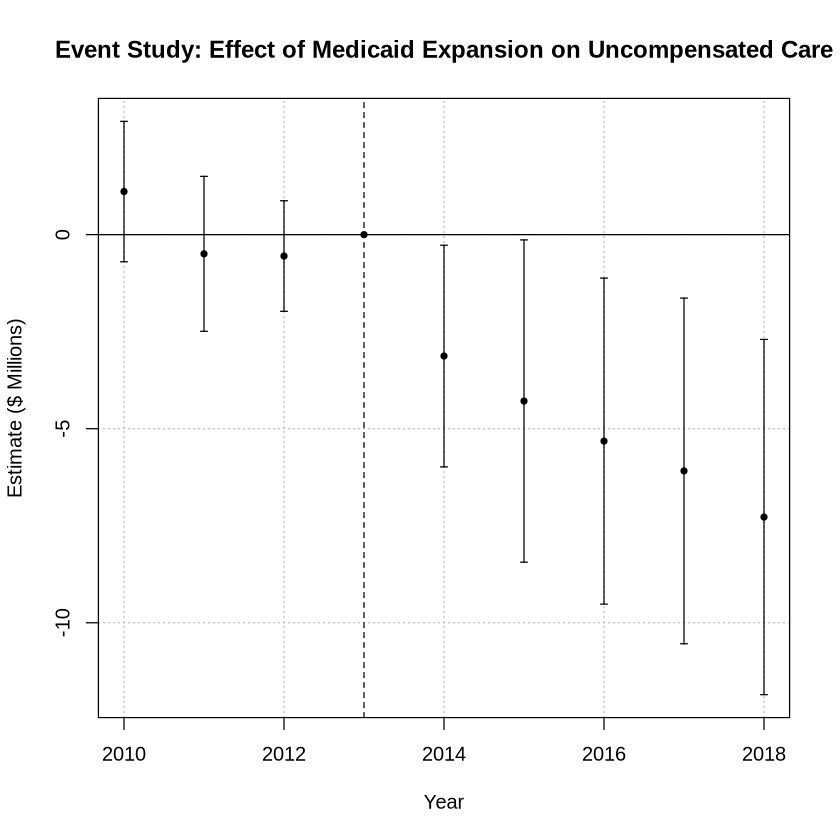

In [21]:
# Filter for 2014 expanders and non expanders
event_study_data <- final_analysis_data %>%
  filter(expansion_year == 2014 | is.na(expansion_year)) %>%
  mutate(
    # 1/0 indicator for if state ever expanded
    treated_state = !is.na(expansion_year)
  )

# Run event study
event_model <- feols(uncomp_millions ~ i(year, treated_state, ref = 2013) | 
                     provider_number + year, 
                     cluster = ~state, 
                     data = event_study_data)

# Plot
iplot(event_model, 
      main = "Event Study: Effect of Medicaid Expansion on Uncompensated Care",
      xlab = "Year", 
      ylab = "Estimate ($ Millions)",
      grid = TRUE)

### Question 9: Repeat part 8 but include all states that expanded after 2014. You will need to construct an “event time” variable and bin end points as discussed in class.

NOTES: 28,518 observations removed because of NA values (LHS: 17,715, RHS: 16,626).
       104/0 fixed-effect singletons were removed (104 observations).



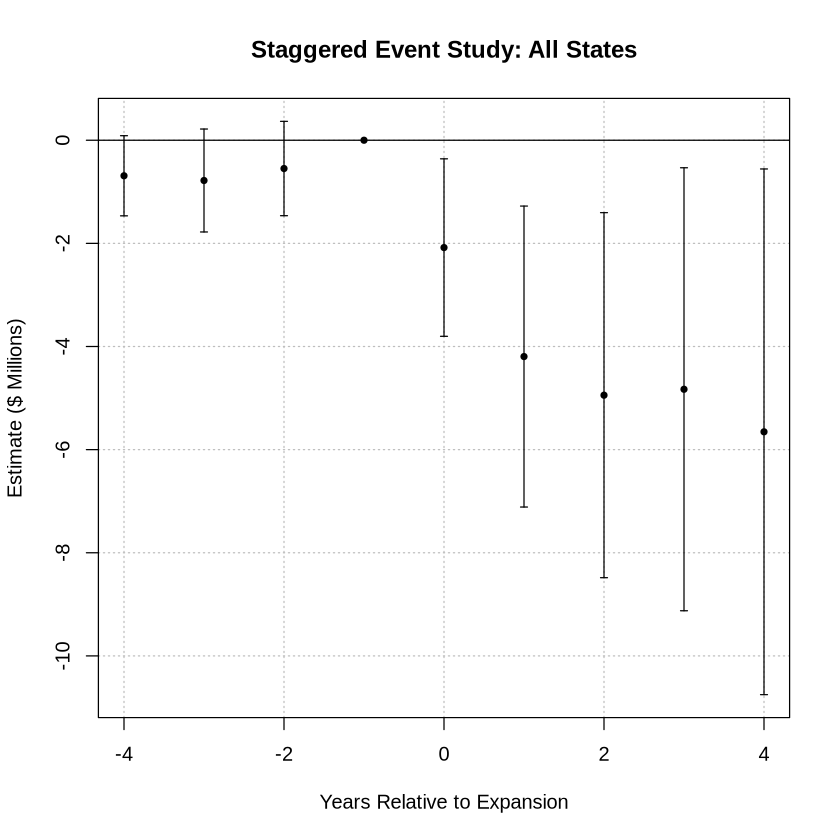

In [20]:
# Create event time variable
final_analysis_data <- final_analysis_data %>%
  mutate(rel_year = year - expansion_year)

# Bind endpoints
final_analysis_data <- final_analysis_data %>%
  mutate(rel_year_binned = case_when(
    rel_year <= -4 ~ -4,
    rel_year >= 4  ~ 4,
    TRUE ~ rel_year
  ))

# Run staggered event reg (ref = -1 as standard baseline year)
event_study_all <- feols(uncomp_millions ~ i(rel_year_binned, ref = -1) | 
                         provider_number + year, 
                         cluster = ~state, 
                         data = final_analysis_data)

# Plot
iplot(event_study_all, 
      main = "Staggered Event Study: All States",
      xlab = "Years Relative to Expansion", 
      ylab = "Estimate ($ Millions)")

### Question 10: Summarize your findings from questions 5-9. What is the effect of Medicaid expansion on hospital uncompensated care? Do the event study graphs suggest any concerns about the parallel trends assumption? Briefly discuss one limitation of the standard TWFE estimator in the context of staggered Medicaid expansion.

Medicaid expansion effectively reduced the financial burden on hospitals. Event studies (Q8 & 9) confirm the research design is valid by showing parallel pre-trends. However, because expansion was staggered over many years, the standard TWFE might slightly underestimate the true effect due to the weighting issues that come up when comparing early-adopters to late-adopters.